In [1]:
import os

import torch
import matplotlib.pyplot as plt

from codes.model import DiffusionUNet
from codes.diffusion import Diffusion

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
image_size = 64

In [3]:
model = DiffusionUNet().to(device)
model.load_state_dict(torch.load('saved_models/best_diffusion_model.pth',map_location=device))
model.eval()
print('model loaded..')

model loaded..


In [4]:
diffusion = Diffusion(device=device)

In [5]:
generated_image = diffusion.sample(model=model,num_images=1, image_size=image_size, device=device)

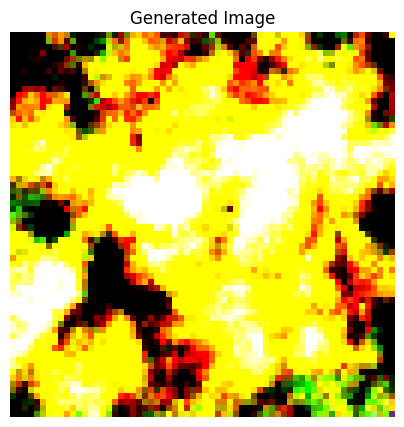

In [6]:
image = generated_image[0].cpu()
image = image.permute(1, 2, 0)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis('off')
plt.title('Generated Image')

plt.show()

In [7]:
os.makedirs('outputs/generated',exist_ok=True)
plt.imsave('outputs/generated/generated_image.png', image.numpy())

to check if the model learned to predict the noise?, or not?,

In [8]:
print('shape :', generated_image.shape)
print('min :', generated_image.min().item())
print('max :', generated_image.max().item())
print('mean :', generated_image.mean().item())
print('std :', generated_image.std().item())

shape : torch.Size([1, 3, 64, 64])
min : 0.0
max : 1.0
mean : 0.5642591118812561
std : 0.46049925684928894


In [37]:
from codes.dataset import create_dataloader

selected_classes = ['Cat', 'Lion', 'Tiger','Horse', 'Elephant']

loader = create_dataloader(dataset_path='animal_data', selected_classes=selected_classes, 
                           batch_size=1,image_size=64,images_per_class=20)

image, _ = next(iter(loader))
image = image.to(device)

In [38]:
timestep = torch.tensor([500]).to(device)
noisy_image, true_noise = diffusion.add_noise(image, timestep)

In [39]:
model.eval()

with torch.no_grad():

    predicted_noise = model(noisy_image, timestep)

In [40]:
alpha_hat = diffusion.alpha_hat[timestep][:, None,None, None]

reconstructed = (noisy_image - torch.sqrt(1 - alpha_hat) * predicted_noise) / torch.sqrt(alpha_hat)
reconstructed = reconstructed.clamp(-1, 1)
reconstructed = (reconstructed + 1) / 2

In [41]:
original = (image.squeeze(0).cpu() + 1) / 2
original = original.permute(1, 2, 0)

noisy = (noisy_image.squeeze(0).cpu() + 1) / 2
noisy = noisy.permute(1, 2, 0)

reconstructed = reconstructed.squeeze(0).cpu()
reconstructed = reconstructed.permute(1, 2, 0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6332805..2.3283815].


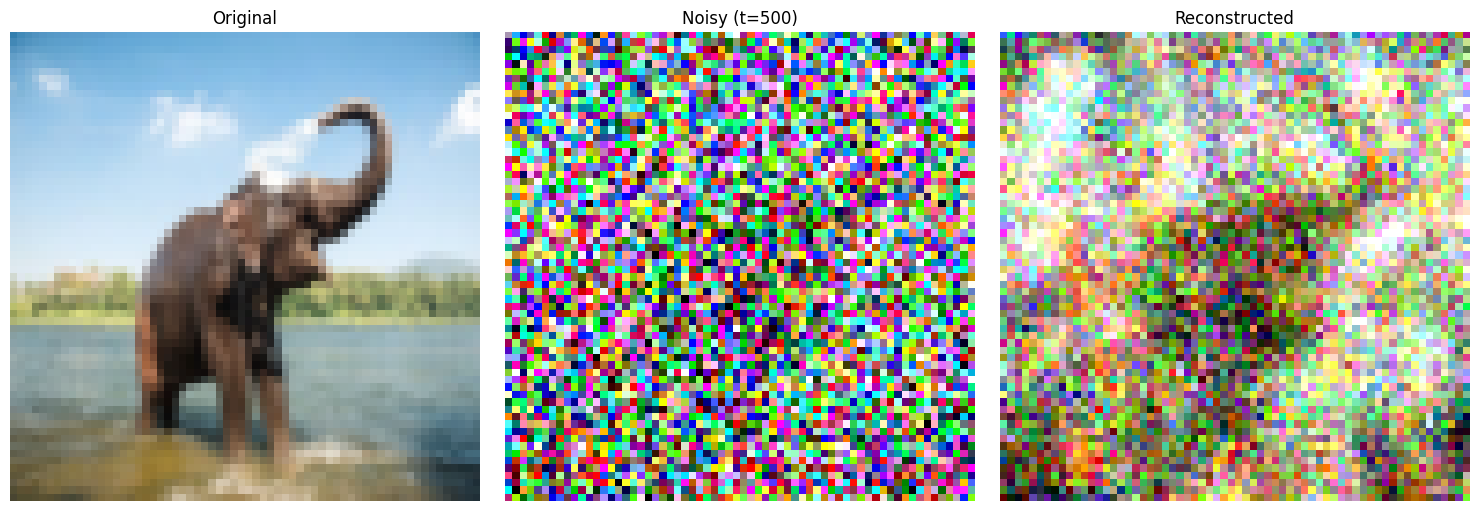

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy)
plt.title('Noisy (t=500)')
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(reconstructed)
plt.title('Reconstructed')
plt.axis('off')

plt.tight_layout()
plt.show()